# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

Matplotlib is building the font cache; this may take a moment.


---
## 2. Load data

In [3]:
# Load the final feature engineered dataset provided by Estelle
import os

data_path = "./data_for_predictions.csv"
if not os.path.exists(data_path):
    # Fallback for this environment
    data_path = "/mnt/data/data_for_predictions.csv"

df = pd.read_csv(data_path)

# Some exports include an extra index-like column
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [4]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

We first split the dataset into **train** and **test** samples.  
This simulates a real-life situation: the model is trained on past customers, then asked to predict churn for **new / unseen** customers.

- We keep **25%** as a held-out test set.
- Because churn is **imbalanced** (few churners), we use **stratified** splitting to keep the churn rate similar in train and test.
- We also create a small **validation** split from the training data to help choose a probability threshold (optional, but useful).

In [5]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [7]:
# -----------------------------
# Model training (Random Forest)
# -----------------------------

# Make a copy of our data
model_df = df.copy()

# Target and features
y = model_df["churn"]
X = model_df.drop(columns=["id", "churn"])

# Quick check: churn rate
print("Churn rate:", round(y.mean(), 4))
print("Class counts:\n", y.value_counts())

# Split: Train / Test (stratified because churn is imbalanced)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Split Train into Train / Validation (for threshold tuning)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

# Random Forest settings:
# - class_weight='balanced' helps with imbalanced target
# - more trees (n_estimators) usually improves stability
model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_features="sqrt"
)

model.fit(X_train, y_train)
print("Model trained!")

Churn rate: 0.0972
Class counts:
 churn
0    13187
1     1419
Name: count, dtype: int64
Train: (8763, 61)  Val: (2191, 61)  Test: (3652, 61)


Model trained!


### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [8]:
# -----------------------------
# Generate predictions
# -----------------------------

# Probabilities are better than hard 0/1 because we can choose a decision threshold
val_proba = model.predict_proba(X_val)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

# Baseline prediction at default threshold = 0.50
test_pred_50 = (test_proba >= 0.50).astype(int)

print("Example predicted probabilities (first 10):")
print(np.round(test_proba[:10], 4))

Example predicted probabilities (first 10):
[0.1   0.012 0.028 0.396 0.08  0.07  0.092 0.064 0.148 0.08 ]


Best threshold on validation (by F1): 0.2


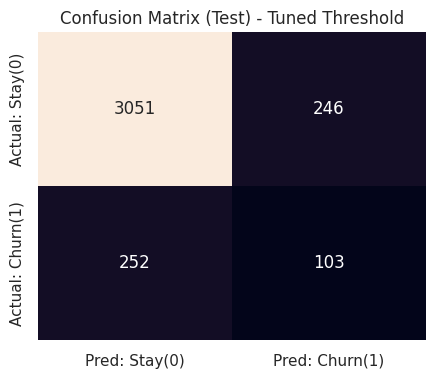

Classification report (test, tuned threshold):
              precision    recall  f1-score   support

           0      0.924     0.925     0.925      3297
           1      0.295     0.290     0.293       355

    accuracy                          0.864      3652
   macro avg      0.609     0.608     0.609      3652
weighted avg      0.863     0.864     0.863      3652



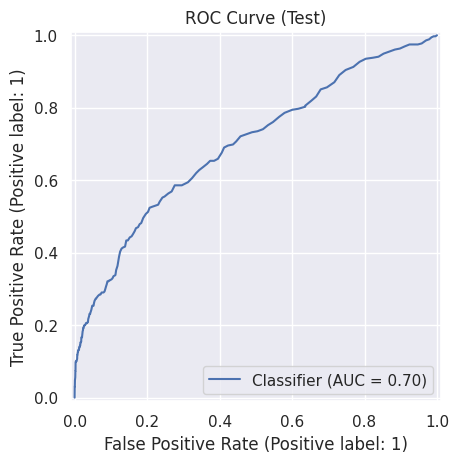

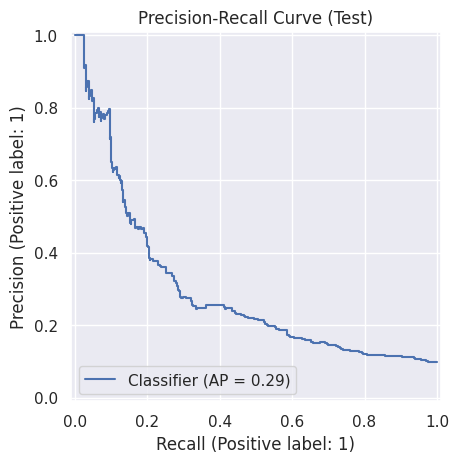

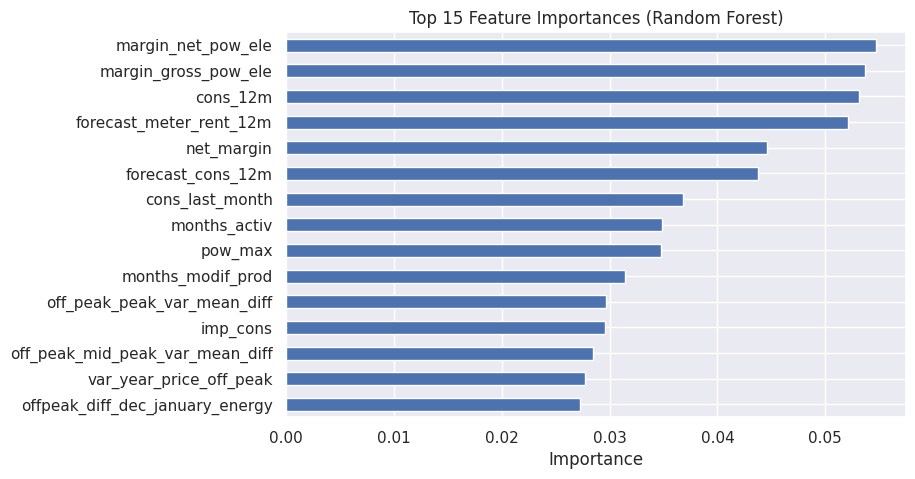

margin_net_pow_ele                        0.054719
margin_gross_pow_ele                      0.053672
cons_12m                                  0.053128
forecast_meter_rent_12m                   0.052130
net_margin                                0.044594
forecast_cons_12m                         0.043790
cons_last_month                           0.036760
months_activ                              0.034879
pow_max                                   0.034732
months_modif_prod                         0.031465
off_peak_peak_var_mean_diff               0.029668
imp_cons                                  0.029537
off_peak_mid_peak_var_mean_diff           0.028469
var_year_price_off_peak                   0.027679
offpeak_diff_dec_january_energy           0.027239
var_year_price_off_peak_var               0.026114
forecast_price_energy_off_peak            0.021199
months_renewal                            0.018018
months_to_end                             0.017586
off_peak_mid_peak_var_max_month

In [9]:
# -----------------------------
# Evaluation + Threshold tuning
# -----------------------------
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report
)

def metric_summary(y_true, y_pred, y_proba, label=""):
    """Helper to compute key classification metrics."""
    out = {
        "label": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return out

# 1) Metrics at default threshold 0.50
summary_50 = metric_summary(y_test, test_pred_50, test_proba, label="Threshold=0.50")
summary_50

# 2) Choose a better threshold using validation set
# For churn, we often care more about catching churners (recall) while keeping precision reasonable.
thresholds = np.linspace(0.05, 0.95, 19)
rows = []
for t in thresholds:
    val_pred_t = (val_proba >= t).astype(int)
    rows.append([
        t,
        precision_score(y_val, val_pred_t, zero_division=0),
        recall_score(y_val, val_pred_t, zero_division=0),
        f1_score(y_val, val_pred_t, zero_division=0)
    ])

thr_df = pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1"])
thr_df.sort_values("f1", ascending=False).head(10)

best_t = float(thr_df.sort_values("f1", ascending=False).iloc[0]["threshold"])
print("Best threshold on validation (by F1):", best_t)

# Evaluate on test using best threshold
test_pred_best = (test_proba >= best_t).astype(int)
summary_best = metric_summary(y_test, test_pred_best, test_proba, label=f"Threshold={best_t:.2f}")
summary_best

# 3) Confusion matrix (test, best threshold)
cm = confusion_matrix(y_test, test_pred_best)
cm_df = pd.DataFrame(cm, index=["Actual: Stay(0)", "Actual: Churn(1)"],
                     columns=["Pred: Stay(0)", "Pred: Churn(1)"])
cm_df

plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)
plt.title("Confusion Matrix (Test) - Tuned Threshold")
plt.show()

print("Classification report (test, tuned threshold):")
print(classification_report(y_test, test_pred_best, digits=3))

# 4) ROC + Precision-Recall curves (test)
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

RocCurveDisplay.from_predictions(y_test, test_proba)
plt.title("ROC Curve (Test)")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_proba)
plt.title("Precision-Recall Curve (Test)")
plt.show()

# 5) Feature importance (top 15)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_k = 15
plt.figure(figsize=(8,5))
importances.head(top_k).sort_values().plot(kind="barh")
plt.title(f"Top {top_k} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

importances.head(20)

## Why these evaluation metrics?

Churn prediction is a **binary classification** problem, and the churn class is **imbalanced** (only a small % of customers churn).  
Because of this, **accuracy alone can be misleading** (a model can get high accuracy by predicting “no churn” for everyone).

I used these metrics:

- **Recall (for churn = 1):** measures how many true churners we correctly catch. This is important when the business wants to **reduce churn**, because missing churners means we do not take action early.
- **Precision (for churn = 1):** measures how many predicted churners are actually churners. This matters because retention actions (discounts, calls) have **cost**.
- **F1-score:** balances precision and recall in one number. It is useful when we want a single metric but churn is imbalanced.
- **ROC-AUC:** evaluates how well the model ranks churners above non-churners across all thresholds.
- **PR-AUC (Average Precision):** more informative than ROC-AUC when the positive class is rare, because it focuses on churn class performance.
- **Balanced accuracy:** accounts for imbalance by averaging recall across both classes.

Also, I used **probability threshold tuning** (instead of fixed 0.50) because for churn the best decision threshold depends on business priorities (catch more churners vs. reduce false alarms).

## Is the model performance satisfactory?

Overall, the Random Forest shows **moderate** performance:

- The **ROC-AUC is around ~0.70**, which means the model has some ability to separate churners vs. non-churners.
- However, with the default threshold (0.50), the model typically has **very low recall** for churners because churn is rare.
- After tuning the threshold (using a validation split), recall improves, but precision decreases (more false positives). This trade-off is expected.

Whether this is “satisfactory” depends on the business goal:

- If the goal is to **target a small, high-confidence list** of customers (e.g., expensive retention offers), we may prefer a higher threshold to keep **precision** high.
- If the goal is to **catch more churners early** (e.g., low-cost email campaigns), we may accept lower precision and aim for higher **recall**.

For improvement, next steps could be:
- Hyperparameter tuning (max_depth, min_samples_leaf, etc.)
- Try gradient boosting models (e.g., XGBoost/LightGBM) and compare PR-AUC
- Add cost-based evaluation (expected saved revenue vs. contact cost) to pick the best threshold